In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("data/ecommerce_sessions.csv")

In [3]:
X = df.drop("Converted", axis=1)
y = df["Converted"]

encoder = LabelEncoder()

X["Month"] = encoder.fit_transform(X["Month"])
X["VisitorType"] = encoder.fit_transform(X["VisitorType"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [5]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(y_test, y_pred))

    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      2025
           1       0.86      0.62      0.72       375

    accuracy                           0.92      2400
   macro avg       0.90      0.80      0.84      2400
weighted avg       0.92      0.92      0.92      2400

Confusion Matrix
[[1987   38]
 [ 144  231]]
Decision Tree
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      2025
           1       0.68      0.69      0.68       375

    accuracy                           0.90      2400
   macro avg       0.81      0.81      0.81      2400
weighted avg       0.90      0.90      0.90      2400

Confusion Matrix
[[1904  121]
 [ 118  257]]
Random Forest
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2025
           1       0.80      0.73      0.76       375

    accuracy                           0.93   

In [6]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.924167,0.858736,0.616000,0.717391
1,Decision Tree,0.900417,0.679894,0.685333,0.682603
2,Random Forest,0.929583,0.802941,0.728000,0.763636
3,KNN,0.910417,0.827869,0.538667,0.652666
4,SVM,0.930417,0.842105,0.682667,0.754050
5,Gradient Boosting,0.933333,0.809798,0.749333,0.778393


In [7]:
results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
5,Gradient Boosting,0.933333,0.809798,0.749333,0.778393
4,SVM,0.930417,0.842105,0.682667,0.754050
2,Random Forest,0.929583,0.802941,0.728000,0.763636
0,Logistic Regression,0.924167,0.858736,0.616000,0.717391
3,KNN,0.910417,0.827869,0.538667,0.652666
1,Decision Tree,0.900417,0.679894,0.685333,0.682603


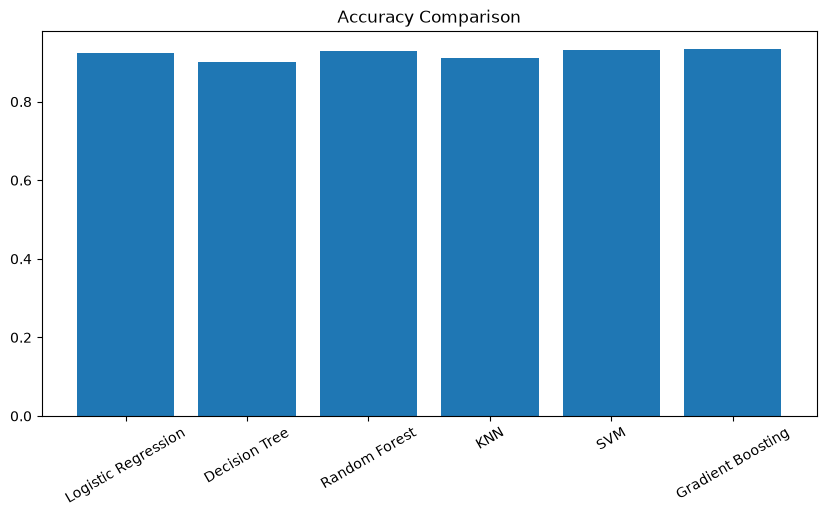

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=30)

plt.title("Accuracy Comparison")

plt.show()